# IS 5540 Project - Final Analysis, Advanced Techniques, and Reporting

## Data Wrangling Summary

In [60]:
# LOAD PACKAGES
load_or_install <- function(pkgs) {
  for(p in pkgs) {
    if(!requireNamespace(p, quietly = TRUE)) {
      message(paste('Installing package:', p))
      install.packages(p)
    }
    library(p, character.only = TRUE)
  }
}

# Load in tidyverse for data manip and plotting
# Lubridate for handling date values
# Scales for formatting for our plots
load_or_install(c('tidyverse', 'lubridate', 'scales', 'broom', 'forcats', 'factoextra', 'tidymodels', 'rpart.plot'))

In [61]:
# LOAD CSV FILE
music <- read.csv("C:\\Users\\coolg\\OneDrive - Harding University\\Courses\\Spring 2026\\IS 5540\\spotify-tracks-dataset.csv") # load csv data

In [62]:
# Adding column to change duration from ms to seconds, and standardize loudness
# Then, filter only unique songs, keeping all the rows
# Then, filter to specific genres (the most popular ones)
# Lastly, select certain columns for data analysis
music_small <- music %>%
  mutate(
    duration_sec = round(duration_ms / 1000, 0),
    loudness = (loudness - mean(loudness)) / sd(loudness)
  ) %>%
  distinct(track_name, .keep_all = TRUE) %>%
  filter(track_genre %in% c("pop", "rock", "hip-hop", "country", "classical", "jazz")) %>%
  select(tempo, mode, popularity, duration_sec, track_genre, track_name, energy, loudness, acousticness)

## Regression Tree Method

In [63]:
# Remove track name from model
music_tree <- music_small %>%
  select(-track_name)

In [64]:
# The recipe is expecting to predict popularity by all available features
rec <- recipe(energy ~ ., music_tree)

# Display the summary stats after the preprocessing.
rec |>
  prep() |>
  bake(new_data = NULL) |>
  summary()

     tempo             mode          popularity     duration_sec       track_genre     loudness         acousticness           energy        
 Min.   :  0.00   Min.   :0.0000   Min.   : 0.00   Min.   :  17.0   classical:745   Min.   :-6.61559   Min.   :0.0000125   Min.   :0.000756  
 1st Qu.: 92.01   1st Qu.:0.0000   1st Qu.: 0.00   1st Qu.: 165.0   country  :507   1st Qu.:-1.42321   1st Qu.:0.1177500   1st Qu.:0.224000  
 Median :113.48   Median :1.0000   Median :31.00   Median : 205.0   hip-hop  :607   Median : 0.04672   Median :0.4635000   Median :0.533000  
 Mean   :116.98   Mean   :0.6696   Mean   :31.96   Mean   : 222.5   jazz     :166   Mean   :-0.58732   Mean   :0.5035108   Mean   :0.490380  
 3rd Qu.:139.93   3rd Qu.:1.0000   3rd Qu.:62.00   3rd Qu.: 247.0   pop      :235   3rd Qu.: 0.54330   3rd Qu.:0.9232500   3rd Qu.:0.730000  
 Max.   :214.02   Max.   :1.0000   Max.   :99.00   Max.   :2647.0   rock     :116   Max.   : 1.62645   Max.   :0.9960000   Max.   :0.994000  

In [65]:
# Define the decision tree
set.seed(42)
tree_music <- decision_tree(mode = "regression",
  tree_depth = 5, # Five levels of splits
  min_n = 4 # Each decision node must contain at least four instances
)

In [66]:
# Define the workflow
wflow_tree <- workflow() |>
  add_recipe(rec) |>
  add_model(tree_music)

# Fit the model
fit_tree <- fit(wflow_tree, music_tree)

# Print out the model
fit_tree

══ Workflow [trained] ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: decision_tree()

── Preprocessor ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
0 Recipe Steps

── Model ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
n= 2376 

node), split, n, deviance, yval
      * denotes terminal node

 1) root 2376 189.478800 0.49037990  
   2) loudness< -0.6094322 788  14.614280 0.16521900  
     4) loudness< -2.007032 483   2.676163 0.09402475 *
     5) loudness>=-2.007032 305   5.613070 0.27796280 *
   3) loudness>=-0.6094322 1588  50.207000 0.65173170  
     6) loudness< 0.3384065 722  17.717180 0.53477420  
      12) acousticness>=0.567 291   5.501752 0.43699310 *
      13

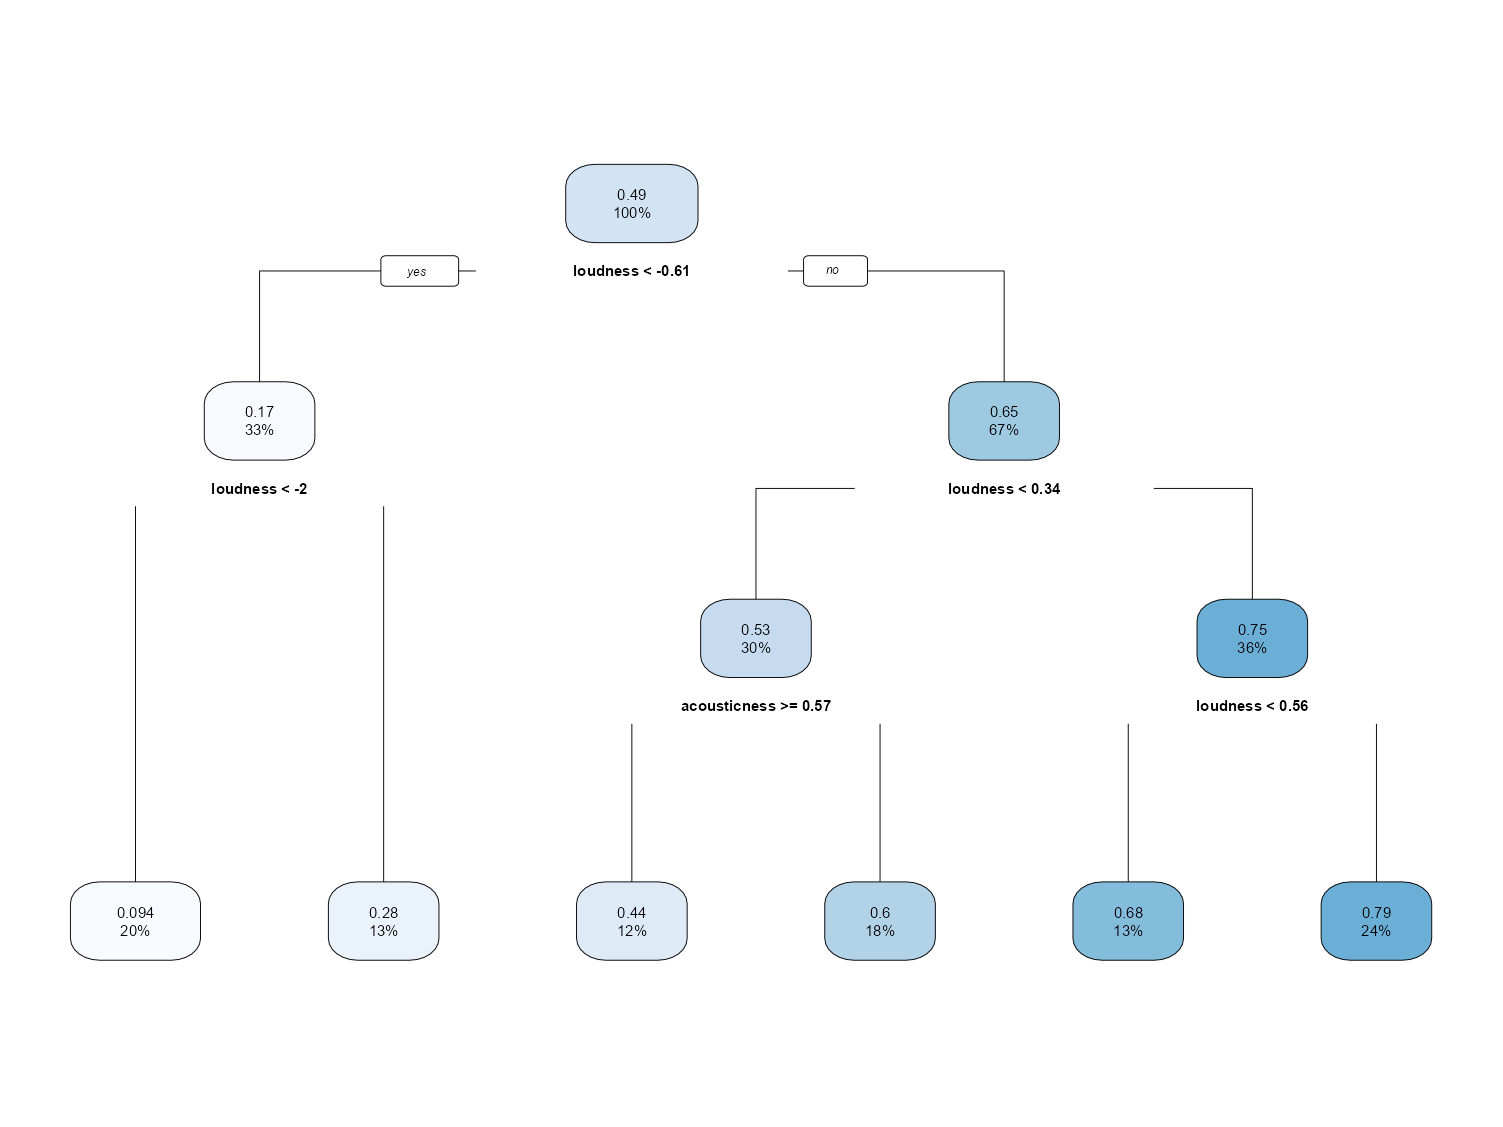

In [67]:
# Plot the tree visually
fit_tree |> extract_fit_engine() |>
  rpart.plot::rpart.plot(roundint = FALSE,
    border.col = 1) # Set border of boxes to black

In [68]:
music_aug <- augment(fit_tree, music_tree)
head(music_aug)

# A tibble: 6 × 10
  .pred   .resid tempo  mode popularity duration_sec track_genre energy loudness acousticness
  <dbl>    <dbl> <dbl> <int>      <int>        <dbl> <chr>        <dbl>    <dbl>        <dbl>
1 0.278 -0.00996 144.      0         58          298 classical    0.268   -1.35         0.593
2 0.787  0.111    92.0     1         59          483 classical    0.898    0.821        0.365
3 0.679 -0.0409  140.      0         54          219 classical    0.638    0.448        0.581
4 0.278  0.0150  144.      0         68          299 classical    0.293   -1.59         0.596
5 0.278  0.0300  118.      0         59          388 classical    0.308   -2.00         0.581
6 0.437  0.125   150.      0         59          307 classical    0.562   -0.208        0.584

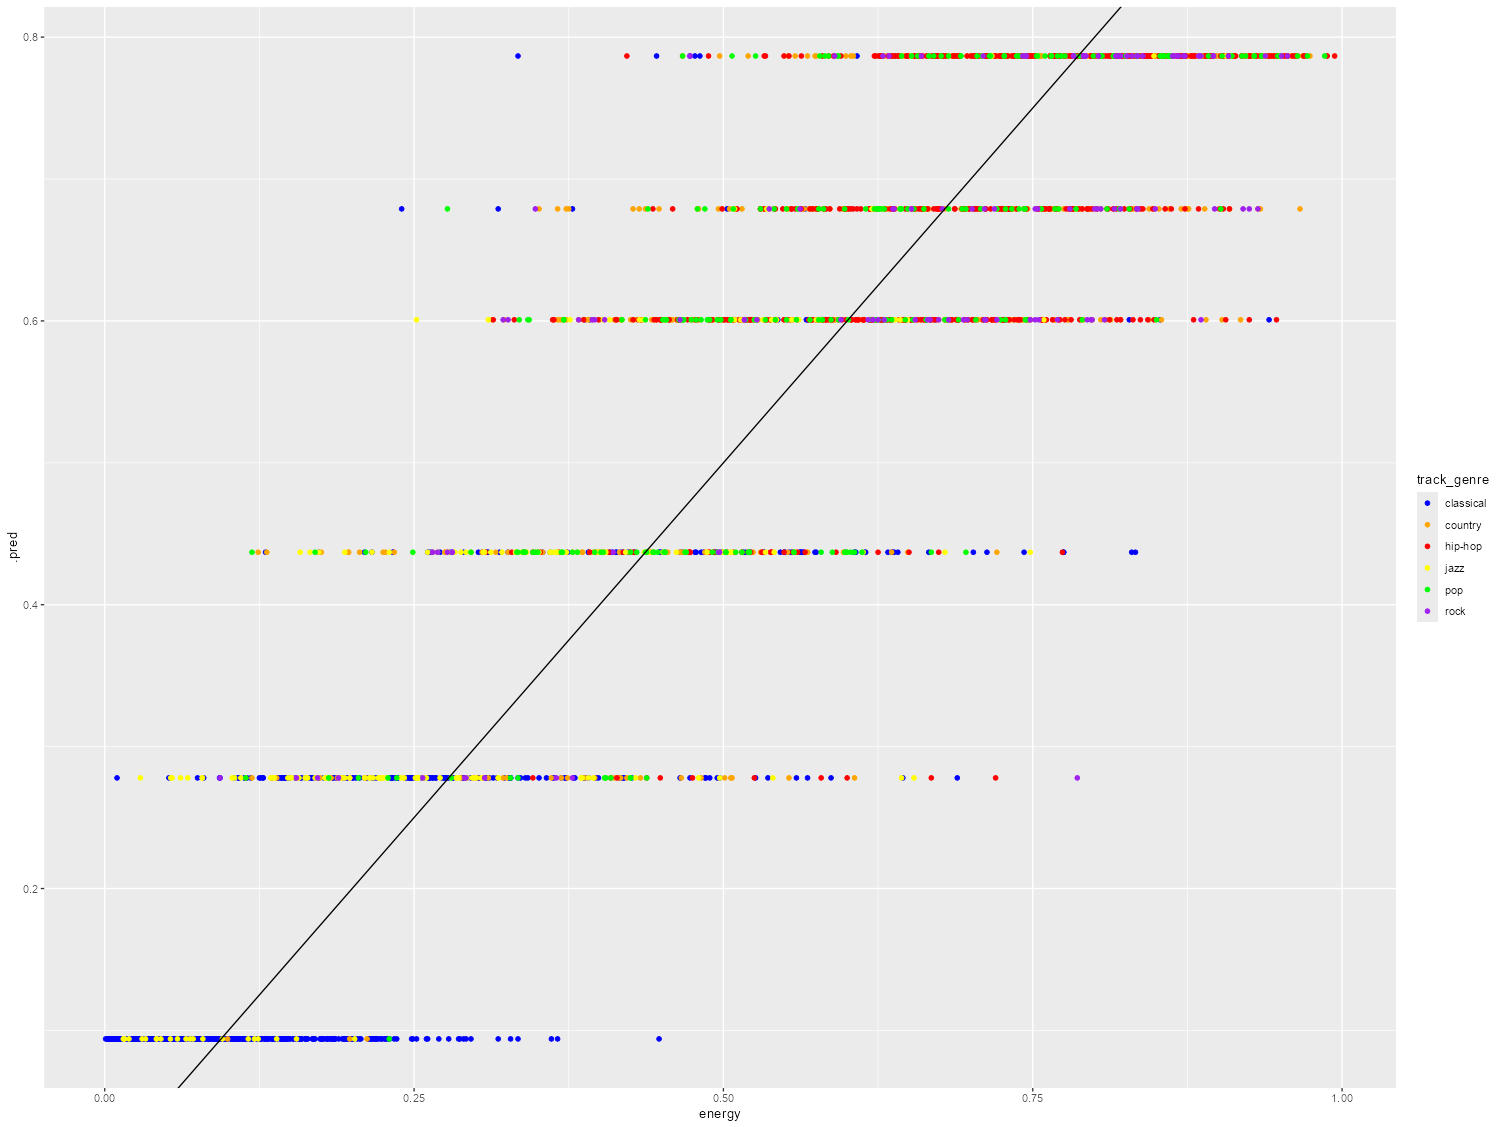

In [69]:
# Plot the actual values against the predicted ones.  All four leaves can be seen.
music_aug |> ggplot(aes(x = energy, y = .pred, col = track_genre)) +
  geom_point() +
  geom_abline(slope = 1, intercept = 0) +
  scale_color_manual(values = c('blue', 'orange', 'red', 'yellow', 'green', 'purple'))

In [70]:
# Calculate the root mean square error for the predictions
rmse(music_aug , truth = energy, estimate = .pred)

# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 rmse    standard       0.119

## K-Means Clustering

In [71]:
# Check unique genres
unique(music_small$track_genre)

[1] "classical" "country"   "hip-hop"   "jazz"      "pop"       "rock"     

In [72]:
# Drop genre (K-Means wants numeric features)
music_numeric <- music_small %>%
  select(-track_genre, -track_name)

head(music_numeric)

    tempo mode popularity duration_sec energy   loudness acousticness
1 143.813    0         58          298  0.268 -1.3548585        0.593
2  91.975    1         59          483  0.898  0.8205775        0.365
3 140.109    0         54          219  0.638  0.4475661        0.581
4 143.804    0         68          299  0.293 -1.5944527        0.596
5 118.226    0         59          388  0.308 -1.9970903        0.581
6 149.820    0         59          307  0.562 -0.2077888        0.584

In [73]:
# Standarize
music_scaled <- scale(music_numeric)

head(music_scaled)

           tempo       mode popularity duration_sec     energy   loudness acousticness
[1,]  0.84892317 -1.4233406  0.8569524   0.50781641 -0.7873121 -0.4946222    0.2375760
[2,] -0.79091383  0.7022768  0.8898668   1.75177418  1.4431353  0.9072900   -0.3677189
[3,]  0.73175129 -1.4233406  0.7252947  -0.02338718  0.5226332  0.6669109    0.2057183
[4,]  0.84863847 -1.4233406  1.1860965   0.51454051 -0.6988023 -0.6490235    0.2455404
[5,]  0.03950712 -1.4233406  0.8898668   1.11298505 -0.6456964 -0.9084945    0.2057183
[6,]  1.03894788 -1.4233406  0.8898668   0.56833327  0.2535634  0.2445818    0.2136827

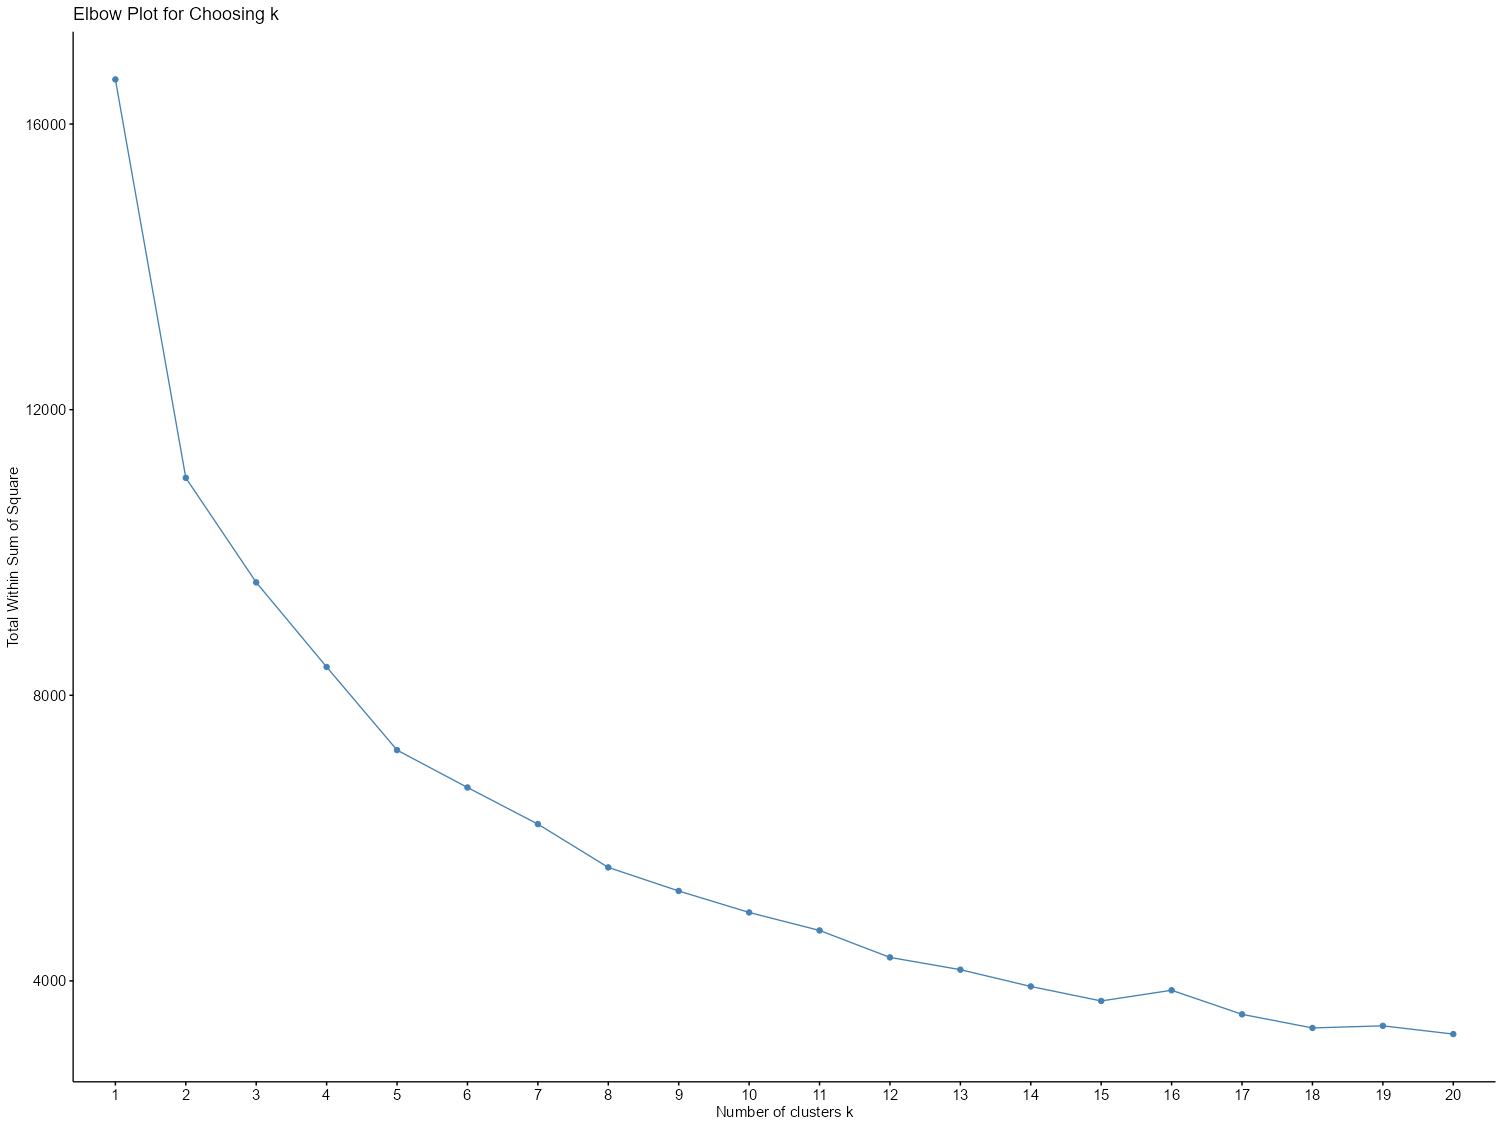

In [74]:
# Elbow Method
# Fit k-means for k = 1, 2, 3, ...
# Plots the total within-cluster sum of squares (WSS)
# As k grows (more clusters = tighter fits), so we look for "elbow" in the plot where the curve bends
# "Diminishing Returns"
fviz_nbclust(music_scaled, kmeans, method = 'wss', k.max = 20) +
  labs(title = 'Elbow Plot for Choosing k')

In [75]:
kmeans_model <- kmeans(music_scaled, centers = 7, nstart = 25)

kmeans_model

K-means clustering with 7 clusters of sizes 343, 196, 342, 18, 585, 425, 467

Cluster means:
       tempo       mode popularity duration_sec     energy    loudness acousticness
1 -0.3583140  0.6960797 -0.1089850   0.20270320 -0.4451873  0.05065705    0.7820735
2 -0.3132607 -1.4233406 -0.6243644  -0.10829604 -1.1795760 -1.22740393    1.0764663
3  0.3994213  0.7022768 -1.0263875  -0.10496108  0.7516511  0.65511136   -0.8696436
4 -0.3196780  0.3480072 -0.1414516   8.04029820 -0.6654833 -0.45802580    1.0672016
5  0.1412247 -1.4233406  0.6120916  -0.03237563  0.6714749  0.62943034   -0.6418068
6 -0.2559541  0.7022768 -0.7578677  -0.29731894 -1.3496877 -1.51084652    1.2115197
7  0.1704859  0.7022768  1.0221588  -0.02533097  0.6843996  0.60232378   -0.7290558

Clustering vector:
   [1] 5 7 5 5 2 5 6 6 6 6 6 6 6 2 6 6 6 6 6 6 1 6 6 2 1 6 2 2 6 6 6 6 6 1 2 6 1 6 1 2 6 6 2 6 6 2 2 6 2 2 6 6 6 2 6 6 6 6 1 2 2 6 6 6 6 5 1 1 1 5 5 7 1 1 4 1 6
  [78] 4 2 6 2 6 2 6 6 2 2 6 2 6 6 6 6 6 6 6 1 2 2 2 2

In [76]:
music_kmeans <- music_small %>%
  mutate(cluster = factor(kmeans_model$cluster))

head(music_kmeans)

    tempo mode popularity duration_sec track_genre             track_name energy   loudness acousticness cluster
1 143.813    0         58          298   classical              Zara Zara  0.268 -1.3548585        0.593       5
2  91.975    1         59          483   classical               Kajra Re  0.898  0.8205775        0.365       7
3 140.109    0         54          219   classical       Zara Zara - Lofi  0.638  0.4475661        0.581       5
4 143.804    0         68          299   classical              Vaseegara  0.293 -1.5944527        0.596       5
5 118.226    0         59          388   classical Zara Zara - LoFi Chill  0.308 -1.9970903        0.581       2
6 149.820    0         59          307   classical            Ondra Renda  0.562 -0.2077888        0.584       5

In [77]:
# Create our principal components
pca_music <- prcomp(music_scaled)
pca_scores <- as.data.frame(pca_music$x[, 1:2]) # grabbing PC1, PC2

# Add pca data into tibble
plot_data <- music_kmeans %>%
  bind_cols(pca_scores)

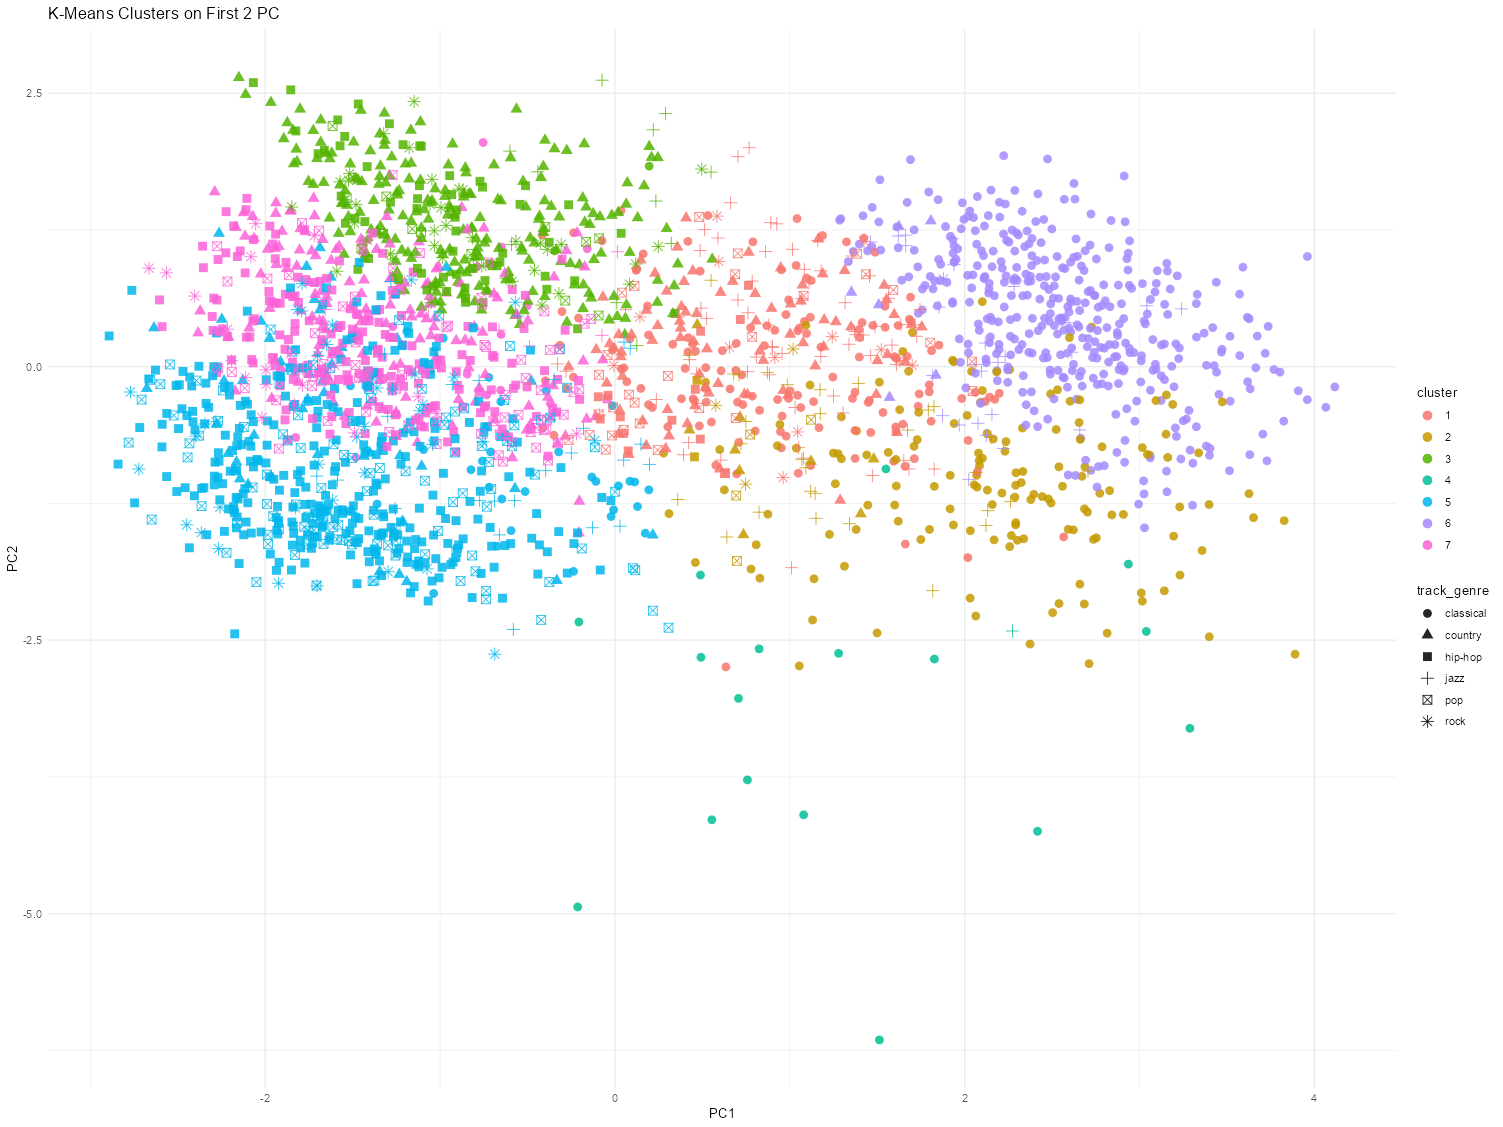

In [78]:
ggplot(plot_data, aes(x = PC1, y = PC2, color = cluster, shape = track_genre)) +
  geom_point(size = 3, alpha = 0.85) +
  labs(
    title = 'K-Means Clusters on First 2 PC',
    x = 'PC1',
    y = 'PC2'
  ) +
  theme_minimal()

In [79]:
fa_model <- factanal(music_scaled, factors = 1, rotation = 'varimax')

print(fa_model, digits = 2, cutoff = 0.3, sort = TRUE)
# cutoff = 0.3 --> hide small loadings to reduce visual noise
# sort = TRUE will group variables by which factor they load on the most


Call:
factanal(x = music_scaled, factors = 1, rotation = "varimax")

Uniquenesses:
       tempo         mode   popularity duration_sec       energy     loudness acousticness 
        0.95         0.98         0.85         1.00         0.04         0.22         0.27 

Loadings:
             Factor1
energy        0.98  
loudness      0.88  
acousticness -0.86  
tempo               
mode                
popularity    0.38  
duration_sec        

               Factor1
SS loadings       2.69
Proportion Var    0.38

Test of the hypothesis that 1 factor is sufficient.
The chi square statistic is 158.94 on 14 degrees of freedom.
The p-value is 1.16e-26 
